# Train and run a simplified global weather model (low hardware and data requirements)

Overview:
- Downloading training data (takes a few minutes)
- Training a neural network to predict global weather conditions (takes around 10 minutes per epoch)
- Inferencing the network on unseen data (takes only a moment)

This demo allows the user to download a 2.8GB file containing around 60 years of global Earth system analysis data. Analysis means the science comnunity's best estimate of historical weather conditions based on available observations. The data set used here was produced by the European Centre for Medium Range Weather Forecasting (ECMWF). This is a standard data set used in the field, however most research is done on a higher-resolution version of the data. That said, there is valuable research done at the lower resolution also. The spatial (latitude and longitude) resolution of this data is 64 pixels by 32 pixels, but the time series is very long. Only a few of the most interesting variables are downloaded in this notebook, for reasons of space.

The data is made available by the ECMWF under license, and the conditions are described here: https://www.ecmwf.int/en/forecasts/accessing-forecasts/licences-available . Please review this before making use of the data for anything. In this tutorial, the data is downloaded using instructions from the weatherbench2 data guide. Please see https://weatherbench2.readthedocs.io/en/latest/data-guide.html for more information on the data, open access, and accessing other resolutions of the data.


In [1]:
import os

# IMPORTANT! Set this to where you want to store your copy of the data!
# os.environ['ERA5LOWRESDEMO'] = os.path.expanduser("~")  # to use your home directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('./')    # to use the current working directory
# os.environ['ERA5LOWRESDEMO'] = os.environ['PBS_JOBFS']  # to use a job-specific temporary directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/tmp')  # to use the /tmp directory

os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/scratch/kd24/tjl548/ML/MiniMax')    # use /tmp by default
EXPERIMENT_VERSION='v7'

import hydra
import pathlib
import xarray as xr
from pathlib import Path

from omegaconf import OmegaConf

import pyearthtools.data.archive
import pyearthtools.tutorial
import pyearthtools.training
import pyearthtools.pipeline

import fourcastnext

# import torch; torch.set_default_device(<YOUR_DEVICE_HERE>)  # Uncomment and set this if you need to configure a non-default device.

In [2]:
workdir = os.environ['ERA5LOWRESDEMO']
print(f'This tutorial will download a copy of the input data to {workdir}. It will also create model checkpoint files and other data here.')

if pyearthtools.data.archive.ROOT_DIRECTORIES['era5lowresdemo'] != workdir:
    print("There is some misconfiguration of your working directory, please review the commented out cells at the start of the notebook")

This tutorial will download a copy of the input data to /scratch/kd24/tjl548/ML/MiniMax. It will also create model checkpoint files and other data here.


In [3]:
file_location = os.environ['ERA5LOWRESDEMO'] + '/mini.nc'

if not os.path.exists(file_location):
    print("Training data not found, downloading around 2.8GB of data")
    era5_lowres = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr')
    subset = era5_lowres[['10m_u_component_of_wind', 
                          '10m_v_component_of_wind', 
                          '2m_temperature', 
                          'mean_sea_level_pressure',
                          'geopotential',
                          'toa_incident_solar_radiation_6hr',
                          'temperature']]

    bilevel = subset.sel({'level': [50, 500]})
    
    # IMPORTANT! Put this somewhere sensible, then set the environment variable as indicated at the start of the tutorial
    bilevel.to_netcdf(file_location)
    print("Wrote file to {file_location}")
    assert os.path.exists(file_location)
else:
    print("File already downloaded, skipping ...")

File already downloaded, skipping ...


In [4]:
accessor = pyearthtools.tutorial.ERA5DataClass.ERA5LowResDemoIndex([
                 '10m_u_component_of_wind', 
                 '10m_v_component_of_wind', 
                 'mean_sea_level_pressure',
                 '2m_temperature'    
],
filename_override=file_location)

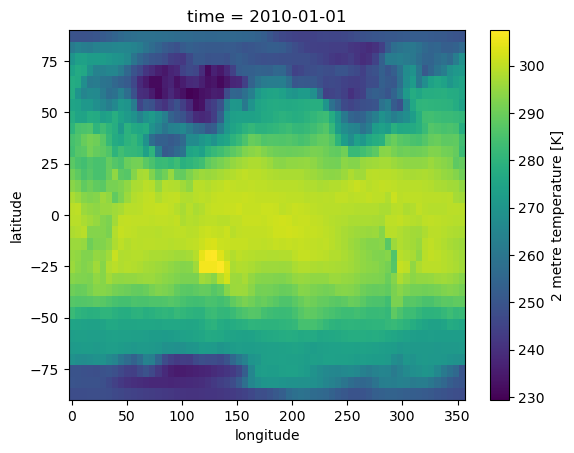

In [5]:
# Print one sample data point from the accessor
accessor['2010-01-01T00']['2m_temperature'].plot(x='longitude', y='latitude')

In [6]:
data_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),    
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 4, 6)) # Input = 1 sample from time T=0 hours. Output = T+6,+12,+18,+24
    ),    
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=os.environ['ERA5LOWRESDEMO'] + 'v7'),  # Incremental normalisation calculator
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours')
)
# data_pipeline

In [7]:
# data_pipeline['2000-01-06T00']

In [8]:
splits = {
    'train_split': pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours'),
    'valid_split': pyearthtools.pipeline.iterators.DateRange(2018, 2020, interval = '6 hours'),
}

# If you encounter memory problems, set the batch size to a lower number, or 1
# If you encounter CPU / multithreading issues, set num_workers to a lower number, or 0
# 0 is a special number which means 'use the main process', whereas '1' will spawn 1 worker
datamodule = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    data_pipeline,
    **splits,
    **{'num_workers': 11, 'batch_size': 8}
)

In [9]:
# If this model doesn't fit on your GPU, reduce the size of the embed_dim to a much lower
# number. This will impact model accuracy but may still produce acceptable outputs.
model = fourcastnext.registered_model.FourCastNextRM(
    pipeline=data_pipeline,       
    lightning_model_params = {'img_size': (64, 32), 
                              'in_channels': 4, 
                              'out_channels': 4,
                              'embed_dim': 768,
                              'num_blocks': 4,  
                              'patch_size': (2,2),
                              'depth': 12,
                             },
    output='.',
    lead_time=6  # Time delta for autoregressive step
)

Setting up PyTorch Lightning Model
{'img_size': (64, 32), 'in_channels': 4, 'out_channels': 4, 'embed_dim': 768, 'num_blocks': 4, 'patch_size': (2, 2), 'depth': 12}


In [10]:
trainer_configuration = {'precision': '32',                          
                         'checkpointing': [
                             {'monitor': 'train_loss', 'mode': 'min', 
                              'dirpath': '{path}/Checkpoints/Train', 
                              'filename': 'model-{epoch:02d}-{step:02d}', 
                              'every_n_train_steps': 1000, 'save_top_k': 10}, 
                             {'monitor': 'valid_loss', 'mode': 'min', 
                              'dirpath': '{path}/Checkpoints/Valid', 
                              'filename': 'model-{epoch:02d}-{step:02d}-{valid_loss}', 
                              'every_n_train_steps': 5000, 'save_top_k': 10}, 
                             {'monitor': 'epoch', 'mode': 'max', 
                              'dirpath': '{path}/Checkpoints/Epoch', 
                              'filename': 'model-{epoch:02d}', 
                              'save_on_train_epoch_end': True, 
                              'save_top_k': 50}]}

checkpoint_path = os.environ['ERA5LOWRESDEMO'] + EXPERIMENT_VERSION



In [11]:
# For a fully converged model, set the max epochs to a much larger number, like
# 40 or even 200.

MAX_EPOCHS = 2

trainer = pyearthtools.training.lightning.Train(
    model.lightning_model,  # We train the lightning model not the registered model?
    datamodule,
    path=checkpoint_path,
    trainer_kwargs={'num_sanity_val_steps': 1, 'max_epochs': MAX_EPOCHS, },
    **trainer_configuration
)

In [ ]:

trainer.fit()

/g/data/kd24/tjl/src/PyEarthTools/packages/training/src/pyearthtools/training/wrapper/lightning/wrapper.py:121: Loading checkpoint: /scratch/kd24/tjl548/ML/MiniMaxv7/Checkpoints/Epoch/model-epoch=00.ckpt


Setting up PyTorch Lightning Model
{'img_size': (64, 32), 'in_channels': 4, 'out_channels': 4, 'embed_dim': 768, 'num_blocks': 4, 'patch_size': (2, 2), 'depth': 12}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/envs/pet/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /scratch/kd24/tjl548/ML/MiniMaxv7/Checkpoints/Train exists and is not empty.
/opt/conda/envs/pet/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /scratch/kd24/tjl548/ML/MiniMaxv7/Checkpoints/Epoch exists and is not empty.
Restoring states from the checkpoint path at /scratch/kd24/tjl548/ML/MiniMaxv7/Checkpoints/Epoch/model-epoch=00.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type    | Params | Mode 
---------------------------------------------
0 | model    | AFNONet | 64.3 M | train
1 | loss_obj | L1Loss  | 0      | train
---------------------------------------------
64.3 M    Trainable params
0         Non-trainable params
64.3 M    Total params
257.056   Total estimated model

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# IMPORTANT! Your checkpoints will be in a unique location based on your training!
# full_checkpoint_path = '/scratch/kd24/tjl548/ML/MiniMax/Checkpoints/Train/model-epoch=00-step=52000.ckpt'
full_checkpoint_path = '/scratch/kd24/tjl548/ML/MiniMaxv5/Checkpoints/Train/model-epoch=00-step=1000.ckpt'


In [ ]:
# We need to reload the registered model with the new checkpoints
pmodel = fourcastnext.registered_model.FourCastNextRM(
    pipeline=data_pipeline,    
    ckpt_path = full_checkpoint_path,
    output='.',
    lead_time=6
)

In [ ]:
# IMPORTANT! This cell must be run to produce prediction data. It produces a lot of debugging information, so it has been commented out for display purposes.
prediction = pmodel.run('2011-01-01T00')

In [ ]:
# Plot prediction
(prediction['2m_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time')

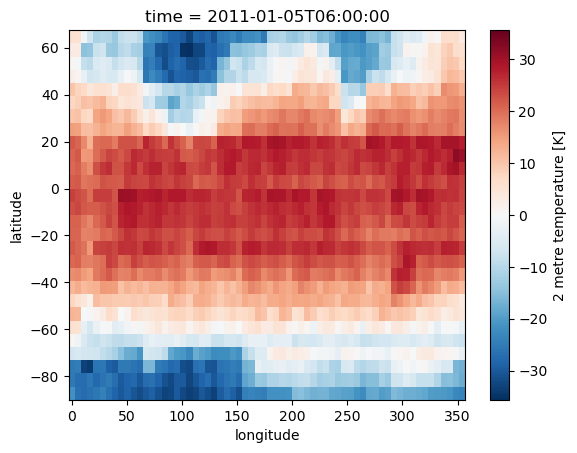

In [28]:
# Plot prediction
LEAD_INTERVAL = 16 # (each interval is an additional 6 hours)
(prediction['2m_temperature'][LEAD_INTERVAL] - 273.15).plot(x='longitude', y='latitude')

In [29]:
prediction

<xarray.Dataset> Size: 1MB
Dimensions:                  (time: 40, longitude: 64, latitude: 28)
Coordinates:
  * longitude                (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude                 (latitude) float64 224B -87.19 -81.56 ... 64.69
  * time                     (time) datetime64[ns] 320B 2011-01-01T06:00:00 ....
Data variables:
    2m_temperature           (time, longitude, latitude) float32 287kB 249.3 ...
    10m_v_component_of_wind  (time, longitude, latitude) float32 287kB -3.438...
    10m_u_component_of_wind  (time, longitude, latitude) float32 287kB -4.205...
    mean_sea_level_pressure  (time, longitude, latitude) float32 287kB 1.001e...
Attributes:
    pyearthtools_models:  Development/FourCastNextRM: 0.1.0
    purpose:              Research Use Only.
    contact:              For further information or support, contact the Dat...
    crpyearthtools:       Generated with `pyearthtools`, a research endeavour...

In [ ]:
# Plot observation
(data_pipeline['2011-01-02T12'][0]['2m_temperature']- 273.15).plot(x='longitude', y='latitude')

# Things to try next

1. This model uses a simple crop to fit the kernel size expected by FourCastNeXt. It would be better to regrid it to the right size.
2. The model needs to train for quite a while to converge. A common problem in machine learning is not knowing quite how long to train a network. Try training it on more data, or for more epochs, and chart out how that affects the training effectiveness as measured by the loss function
3. This notebook doesn't include any comparisons to benchmarks such as a persistence model or an alternative model. Charting skill score comparisons would be very useful.
4. A scorecard of results can also be informative, to see accuracy from multiple perspectives
5. Charting the skill of the model with respect to lead time would also be a useful exercise